# Thresholding an image with pyclesperanto

This notebook demonstrates several ways to binarize the `blobs.png` sample image with
`pyclesperanto`: a manual/logical-operator threshold, and the automatic `Otsu`, `mean`, and
`Yen` threshold methods.

In [1]:
import numpy as np
from skimage.io import imread
import pyclesperanto as cle
import matplotlib.pyplot as plt

cle.select_device()

(OpenCL) Apple M5 Max (OpenCL 1.2)
	Vendor:                      Apple
	Driver Version:              1.2 1.0
	Device Type:                 GPU
	Compute Units:               40
	Global Memory Size:          53084 MB
	Local Memory Size:           0 MB
	Maximum Buffer Size:         9953 MB
	Max Clock Frequency:         1000 MHz
	Image Support:               Yes

## Load the example image

array([[ 40,  32,  24, ..., 216, 200, 200],
       [ 56,  40,  24, ..., 232, 216, 216],
       [ 64,  48,  24, ..., 240, 232, 232],
       ...,
       [ 72,  80,  80, ...,  48,  48,  48],
       [ 80,  80,  80, ...,  48,  48,  48],
       [ 96,  88,  80, ...,  48,  48,  48]], shape=(254, 256), dtype=uint8, mtype=buffer)
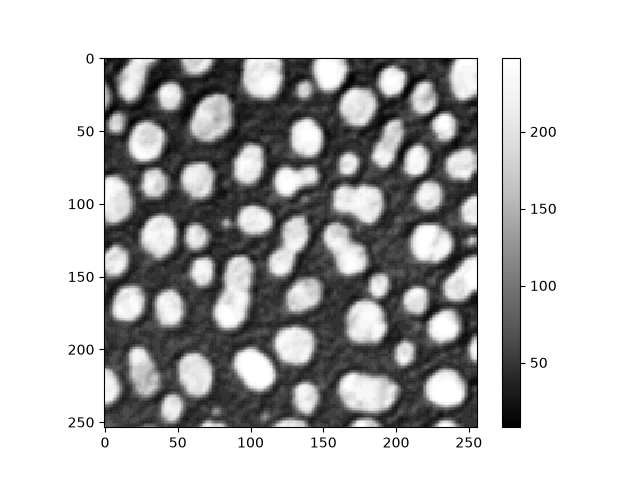
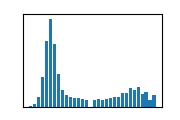

In [2]:
image = cle.push(imread('https://samples.fiji.sc/blobs.png').squeeze())
image

## 1. Manual threshold with a logical operator

The simplest way to binarize an image is to compare it against a fixed intensity value using a
logical operator (`>`, `>=`, `<`, `<=`, `==`). The result is a binary mask, same as
`cle.greater_constant()`.

array([[0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [0, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0]], shape=(254, 256), dtype=uint8, mtype=buffer)
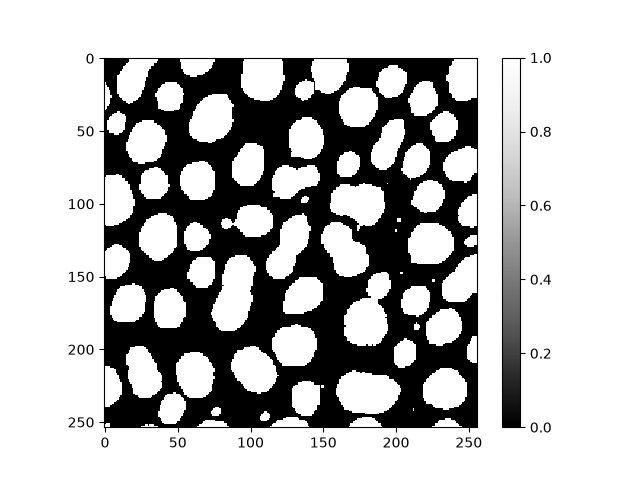
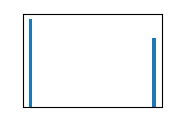

In [3]:
manual_threshold = 75
binary_manual = image > manual_threshold
binary_manual

## 2. Automatic threshold

automatic threshold finds a threshold value based on the global image histogram.
For example, the `otsu` try to minimise the inter-class intensity variance (Otsu et al., 1979).
Other similar algorithm exist with some small differences, such a `Li`, `Triangle`, or `IsoData`.

In [4]:
binary_otsu = cle.threshold_otsu(image)
binary_li = cle.threshold_li(image)
binary_triangle = cle.threshold_triangle(image)
binary_yen = cle.threshold_yen(image)
binary_isodata = cle.threshold_isodata(image)

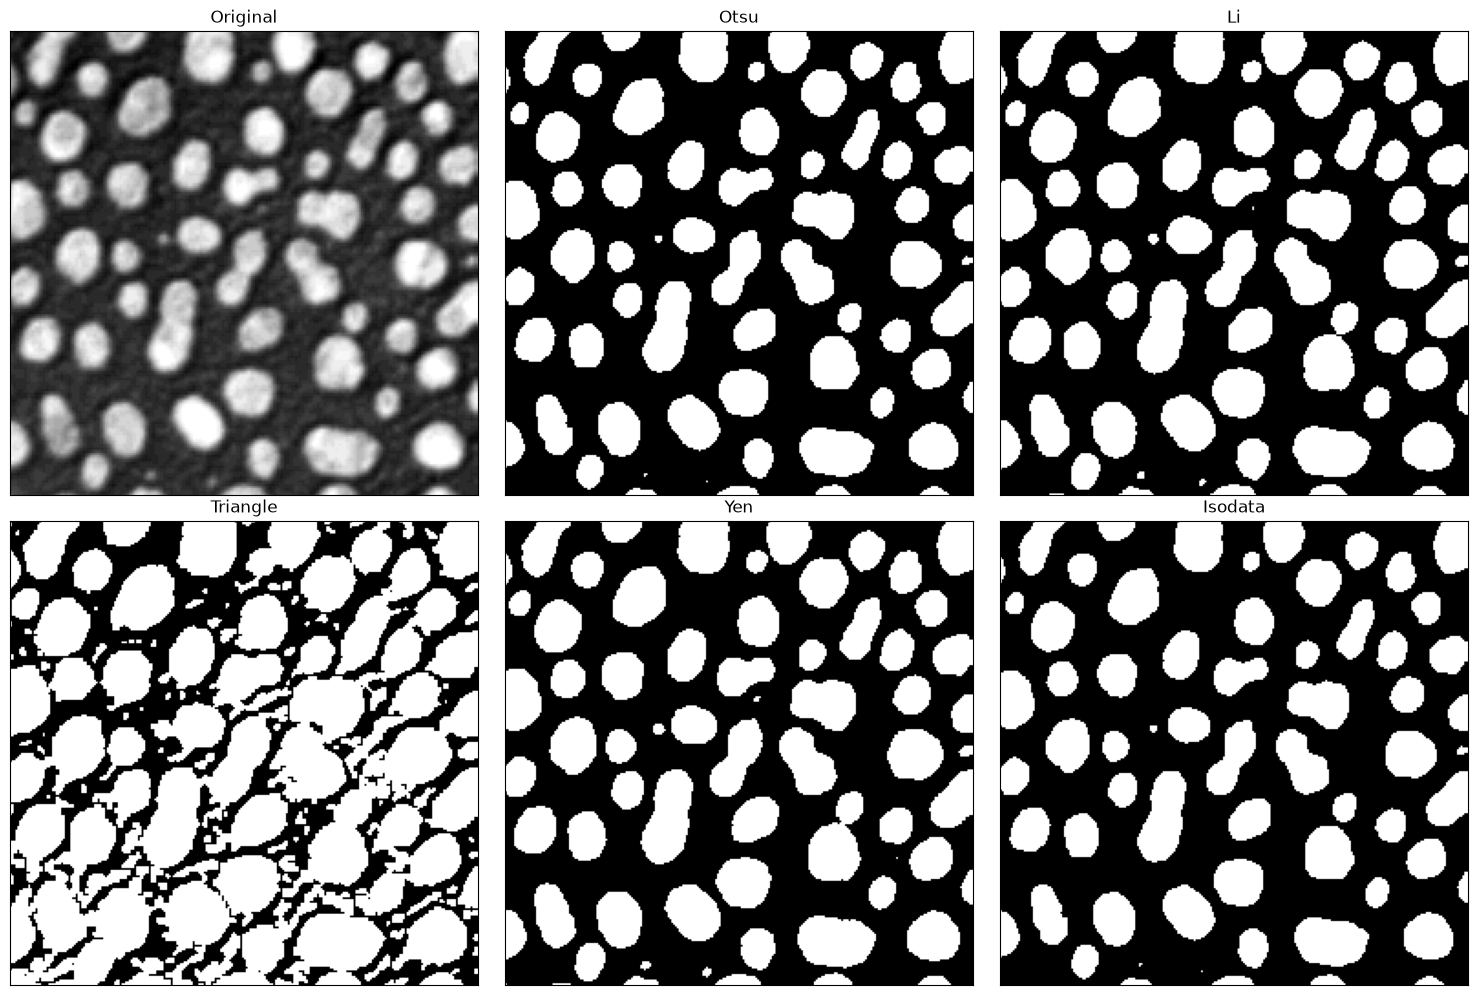

In [8]:
# plot the 6 binary images
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 1].imshow(cle.pull(binary_otsu), cmap='gray')
axes[0, 1].set_title('Otsu')
axes[0, 2].imshow(cle.pull(binary_li), cmap='gray')
axes[0, 2].set_title('Li')
axes[1, 0].imshow(cle.pull(binary_triangle), cmap='gray')
axes[1, 0].set_title('Triangle')
axes[1, 1].imshow(cle.pull(binary_yen), cmap='gray')
axes[1, 1].set_title('Yen')
axes[1, 2].imshow(cle.pull(binary_isodata), cmap='gray')
axes[1, 2].set_title('Isodata')

# remove axis ticks
for ax in axes.flatten():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

> Note:
> Threshold output are binary (0/1 values) but GPU does not support `bool` type, data are return as `uint8` type.